In [3]:
import random
import networkx as nx
import torch
from torch_geometric.data import Data, Dataset

In [23]:
def generate_watts_strogatz(n_nodes, with_label=False,k_min=4,k_max=10):
    """
    Watts-Strogatz small-world graph.
    - k: number of nearest neighbours to connect (even integer)
    - p: rewiring probability in [0, 1]
    """
    k = random.randint(k_min,k_max)
    p = random.uniform(0.0, 1.0)
    G = nx.watts_strogatz_graph(n=n_nodes, k=k, p=p)

    if with_label == True:
        return G, p, k
    else:
        return G


def generate_barabasi_albert(n_nodes, with_label=False,m_min=1, m_max=20):
    """
    Barabási-Albert scale-free graph.
    - m: number of edges to attach from a new node to existing nodes
    """
    m = random.randint(m_min, m_max)
    G = nx.barabasi_albert_graph(n=n_nodes, m=m)

    if with_label == True:
        return G, m
    else:
        return G


def generate_random_regular(n_nodes, with_label=False, degree_min=2, degree_max=20):
    """
    Random regular graph where every node has degree d.
    Requires d * n_nodes to be even.
    """
    d = random.randint(degree_min, min(degree_max, n_nodes - 1))
    if (d * n_nodes) % 2 != 0:
        d = d + 1 if d + 1 < n_nodes else d - 1

    G = nx.random_regular_graph(d=d, n=n_nodes)

    if with_label == True:
        return G, d
    else:
        return G

Example of how a Dataset can be created:

In [24]:
class WattsStrogatzDataset(Dataset):
    """
    Each item is a Watts-Strogatz small-world graph with randomly sampled
    parameters (k, p). The label `y` is the rewiring probability p in [0, 1].
    """
    def __init__(self, dataset_size, n_nodes):
        self.dataset_size = dataset_size
        self.n_nodes = n_nodes

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):

        G, p, k = generate_watts_strogatz(self.n_nodes, with_label=True)

        # get the adjacency matrix from the nx graph
        A = nx.adjacency_matrix(G).todense()
        A = torch.from_numpy(A) * 1.0

        # get the edge indices from the adjacency matrix
        edge_index = A.nonzero(as_tuple=False).T

        # Create the graph data object
        graph = Data(
            edge_index=edge_index, 
            y=[p],
        )

        return graph

ws_dataset = WattsStrogatzDataset(
    dataset_size=200,
    n_nodes=100,
)

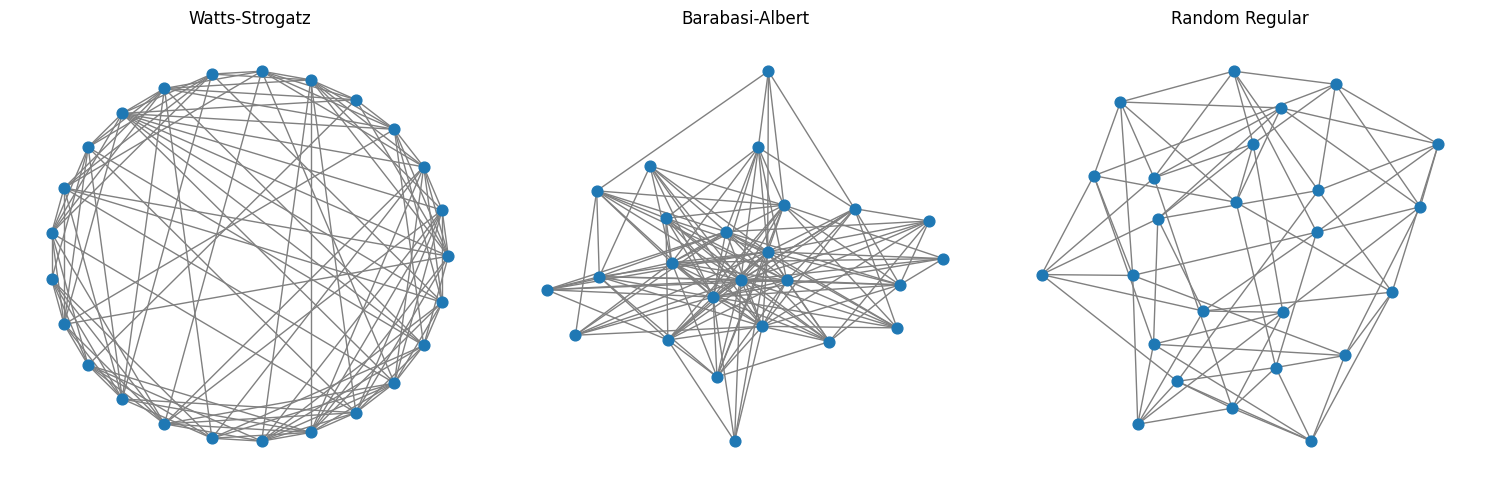

In [25]:
import matplotlib.pyplot as plt
from pygsp import graphs

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

num_nodes = 25

G = generate_watts_strogatz(num_nodes)
pos = graphs.Ring(N = num_nodes).coords
nx.draw(G, pos, ax=axs[0], node_size=60,
            edge_color="gray", with_labels=False)
axs[0].set_title("Watts-Strogatz")

G = generate_barabasi_albert(num_nodes)
pos = nx.spring_layout(G)
nx.draw(G, pos, ax=axs[1], node_size=60,
            edge_color="gray", with_labels=False)
axs[1].set_title("Barabasi-Albert")

G = generate_random_regular(num_nodes)
pos = nx.spring_layout(G)
nx.draw(G, pos, ax=axs[2], node_size=60,
            edge_color="gray", with_labels=False)
axs[2].set_title("Random Regular")

plt.tight_layout()
plt.show()

In [26]:
import numpy as np


#May want to use Scipy Sparse Arrays for large graphs
print(nx.convert_matrix.to_numpy_array(G))

[[0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.
  0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1.
  1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
  1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0.
  0.]
 [0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.
  0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  1.]
 [1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1.
  0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.
  1.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.

In [27]:
import random
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data


class GraphFamilyDataset(Dataset):
    """
    Frozen graph classification dataset:

        0 -> Watts-Strogatz
        1 -> Barabasi-Albert
        2 -> Random Regular

    Only topology is used (no node features).
    """

    def __init__(self, dataset_size, n_nodes_min, n_nodes_max):
        self.dataset_size = dataset_size
        self.n_nodes_min = n_nodes_min
        self.n_nodes_max = n_nodes_max

        self.generators = [
            generate_watts_strogatz,
            generate_barabasi_albert,
            generate_random_regular,
        ]

        # balanced labels
        base_labels = [0, 1, 2] * (dataset_size // 3)
        remainder = [i for i in range(dataset_size % 3)]
        labels = base_labels + remainder
        random.shuffle(labels)

        self.data_list = []

        for label in labels:
            n_nodes = random.randint(self.n_nodes_min,self.n_nodes_max)
            G = self.generators[label](n_nodes)

            edge_index = self.graph_to_edge_index(G)

            # featureless nodes
            x = torch.ones((n_nodes, 1), dtype=torch.float)

            data = Data(
                x=x,
                edge_index=edge_index,
                y=torch.tensor(label, dtype=torch.long),
            )

            self.data_list.append(data)

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        return self.data_list[idx]

    def graph_to_edge_index(self, G):
        edges = list(G.edges())

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

        # make undirected
        edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

        return edge_index

In [28]:
train = GraphFamilyDataset(dataset_size=100,n_nodes_min=50, n_nodes_max=100)

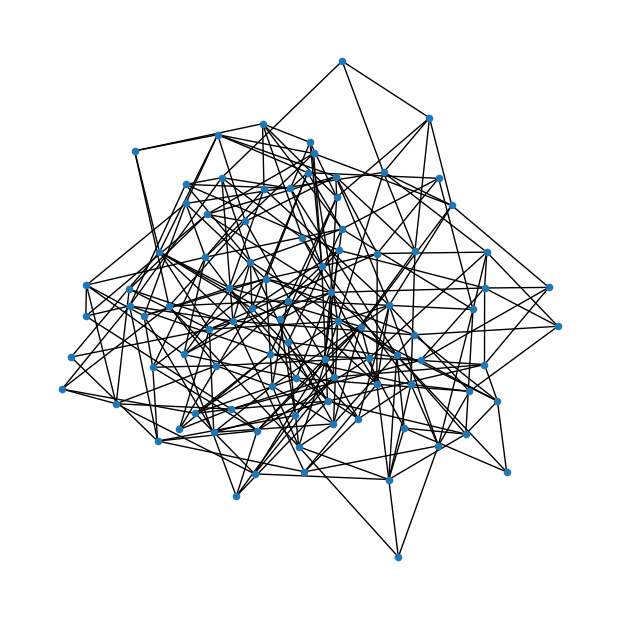

In [29]:
from torch_geometric.utils import to_networkx

sample = train[9]

G = to_networkx(sample, to_undirected=True)

plt.figure(figsize=(6,6))
nx.draw(
    G,
    node_size=20,
    with_labels=False
)
plt.show()

In [30]:
import torch
import torch.nn.functional as F
from torch import nn

from torch_geometric.nn import GCNConv, global_mean_pool


class SpatialGCN(nn.Module):
    def __init__(self, hidden_dim=64, num_classes=3):
        super().__init__()

        # node input dim = 1 because x = ones(...)
        self.conv1 = GCNConv(1, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # message passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # graph-level embedding
        x = global_mean_pool(x, batch)

        # classification
        out = self.classifier(x)

        return out

In [31]:
from torch_geometric.loader import DataLoader

train_dataset = GraphFamilyDataset(5000, n_nodes_min=50, n_nodes_max=150)
val_dataset   = GraphFamilyDataset(1000, n_nodes_min=50, n_nodes_max=150)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpatialGCN(hidden_dim=64, num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss() #Do we want to change this?

def train_epoch():
    model.train()
    total_loss = 0
    total_correct = 0
    total_graphs = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

        preds = out.argmax(dim=1)
        total_correct += (preds == data.y).sum().item()
        total_graphs += data.num_graphs

    return total_loss / total_graphs, total_correct / total_graphs

@torch.no_grad()
def evaluate():
    model.eval()

    total_correct = 0
    total_graphs = 0

    for data in val_loader:
        data = data.to(device)

        out = model(data)
        preds = out.argmax(dim=1)

        total_correct += (preds == data.y).sum().item()
        total_graphs += data.num_graphs

    return total_correct / total_graphs

In [33]:
for epoch in range(1, 31):
    train_loss, train_acc = train_epoch()
    val_acc = evaluate()

    print(f"Epoch {epoch:03d} | Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

Epoch 001 | Loss 1.0989 | Train Acc 0.3298 | Val Acc 0.3330
Epoch 002 | Loss 1.0979 | Train Acc 0.3328 | Val Acc 0.3340
Epoch 003 | Loss 1.0951 | Train Acc 0.3738 | Val Acc 0.3360
Epoch 004 | Loss 1.0524 | Train Acc 0.4998 | Val Acc 0.7290
Epoch 005 | Loss 0.4701 | Train Acc 0.8774 | Val Acc 0.9260
Epoch 006 | Loss 0.1612 | Train Acc 0.9664 | Val Acc 0.9600
Epoch 007 | Loss 0.1056 | Train Acc 0.9724 | Val Acc 0.9730
Epoch 008 | Loss 0.0911 | Train Acc 0.9760 | Val Acc 0.9870
Epoch 009 | Loss 0.0815 | Train Acc 0.9760 | Val Acc 0.9680
Epoch 010 | Loss 0.0696 | Train Acc 0.9812 | Val Acc 0.9880
Epoch 011 | Loss 0.0861 | Train Acc 0.9740 | Val Acc 0.6660
Epoch 012 | Loss 0.1048 | Train Acc 0.9648 | Val Acc 0.9890
Epoch 013 | Loss 0.0749 | Train Acc 0.9750 | Val Acc 0.9670
Epoch 014 | Loss 0.0622 | Train Acc 0.9816 | Val Acc 0.9880
Epoch 015 | Loss 0.0915 | Train Acc 0.9720 | Val Acc 0.9720
Epoch 016 | Loss 0.0547 | Train Acc 0.9852 | Val Acc 0.9840
Epoch 017 | Loss 0.0430 | Train Acc 0.98

In [39]:
test_dataset = GraphFamilyDataset(dataset_size=2000, n_nodes_min=50, n_nodes_max=150)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [40]:
import torch

def evaluate_model(model, loader, device):
    #turns off training setting for layers like dropout, BatchNorm, etc. Don't think we need it but nice to have just in case
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            preds = out.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())

    return torch.cat(all_preds), torch.cat(all_labels)

In [41]:
from sklearn.metrics import confusion_matrix
import numpy as np

In [42]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots()

    im = ax.imshow(cm, cmap="Blues")

    ax.set_title("Graph Family Confusion Matrix")

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))

    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center", color="black")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return cm

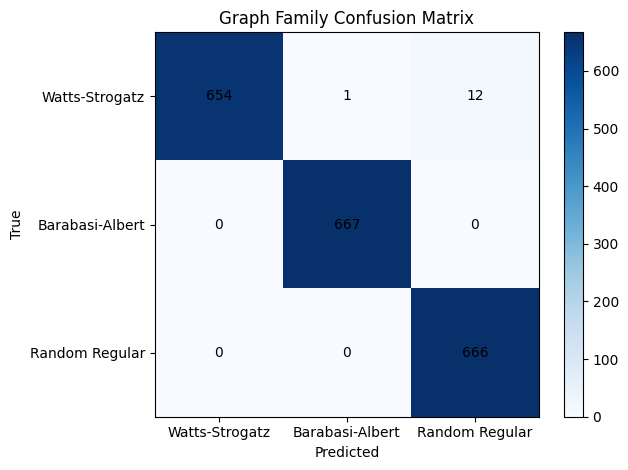

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

y_pred, y_true = evaluate_model(model, test_loader, device)

class_names = [
    "Watts-Strogatz",
    "Barabasi-Albert",
    "Random Regular"
]

cm = plot_confusion_matrix(y_true.numpy(), y_pred.numpy(), class_names)